# Waveguide bend
 wavelength dependent S-parameters for Euler vs circular waveguide bend in SOI

## Parameters

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import gdsfactory as gf
from gdsfactory.technology import LogicalLayer, LayerLevel, LayerStack
import luminescent as lm

# simulation folder
path = os.path.join("runs", "bend")

# length units are arbitrary so long as they're consistent
wavelength = 1.55
bandwidth = 0.1
nwls = 51
wavelengths = np.linspace(wavelength - bandwidth / 2, wavelength + bandwidth / 2, nwls)

# horizontal dims
r = 5
w_wg = 0.5

margin = 0.8
source_offset = 2

# vertical dims
h_wg = 0.22

zmargin = 0.8
zmin = 0
zmax = h_wg / 2 + zmargin

# vertical midplane symmetry as PMC boundary on z-
boundaries = ["PML", "PML", ("PMC", "PML")]

# simulation parameters
nres = 6
subpixel_smoothing = 1
stop_decay = 1e-3
tmax = 100
PML_decay = [0.001, 0.001, 0.1]  # x y z
views = [lm.View("Hz", y="half", z=0)]
frame_every = 5

# materials
material_core = "Si"
material_clad = "SiO2"
materials = {
    "Si": lm.Material(3.5),
    "SiO2": lm.Material(1.5),
}
background = material_clad

# layers
WG = 1, 0
CLAD = 2, 0
layer_stack = LayerStack(
    layers={
        "core": LayerLevel(
            layer=LogicalLayer(layer=WG),
            thickness=h_wg / 2,
            zmin=0,
            material=material_core,
            mesh_order=1,
        )
    }
)

## Geometry

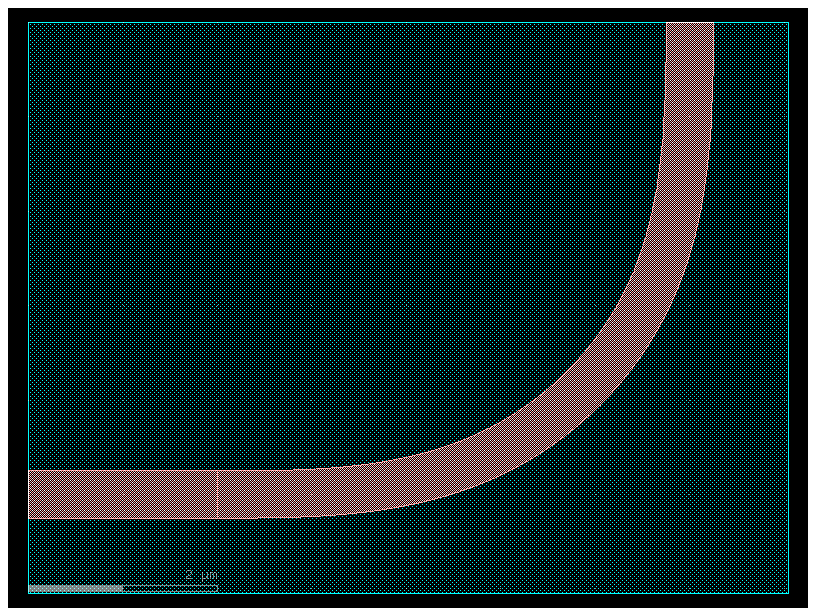

In [2]:
# make component in gdsfactory. alternatively can import .gds into gdsfactory
c = gf.Component()

# Euler or circular bend
b = c << gf.components.bend_euler(r)
# b = c << gf.components.bend_circular(r)
s = c << gf.components.straight(length=source_offset, width=w_wg)

s.connect("o2", b.ports["o1"])
c << gf.components.bbox(component=c, layer=CLAD, right=margin, bottom=margin)

c.add_port("o1", port=b.ports["o1"])
c.add_port("o2", port=b.ports["o2"])

c.plot()

## Setup

origin: [0.0, 0.0, 0.0], basis: [[-1.2246467991473532e-16, -1.0, 0], [0, 0, 1], [-1.0, 1.2246467991473532e-16, 0]], start: [-1.05, 0], stop: [1.05, 0.91],
polyeps: [(<POLYGON ((-0.25 0.0004, -0.25 0.11, -0.248 0.11, 0.25 0.11, 0.25 0.11, 0.25...>, 12.25, 'core'), (<POLYGON ((-0.25 0.11, 0.25 0.11, 0.25 0, -0.25 0, -0.25 0.11))>, 12.25, 'core'), (<POLYGON ((1.05 0, 1.05 0.91, -1.05 0.91, -1.05 0, 1.05 0))>, 2.25, '')]
showing modes for wavelength 1.55
mode Boundary conditions: 0A00


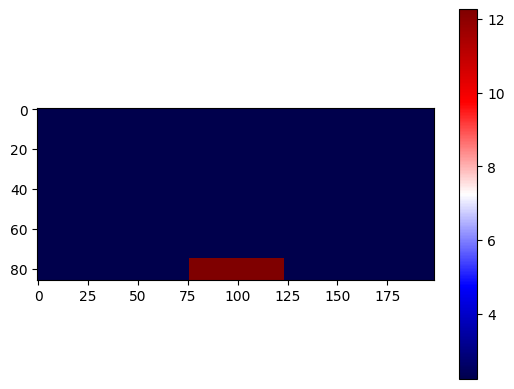

wg_mode\1.55 mode 0 (neff=2.529+0.000j)
saving mode to c:\Users\weihu\OneDrive\Desktop\rock\moon\luminescent\runs\bend\modes\wg_mode\1.55\0.npz
using simulation folder c:\Users\weihu\OneDrive\Desktop\rock\moon\luminescent\runs\bend


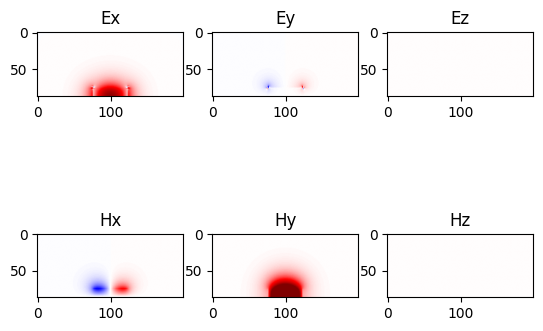

In [3]:
bbox = c.bbox_np().tolist()
bbox[0].append(zmin)
bbox[1].append(zmax)

w_port = w_wg + 2 * margin
frames = [
    lm.Frame(
        "wg_mode",
        start=[-w_port / 2, zmin],
        stop=[w_port / 2, zmax],
        boundaries=["PML", ["PMC", "PML"]],
        nmodes=1,
        modes="auto",
        mode_solver_wavelengths=[wavelength],
    ),
    lm.Frame("wg_signal", points=[[0, 0]], time_response=True),
]

origin, basis = lm.from_gf_port(c, "o1", source_offset)
sources = [
    lm.Source(
        "src",
        origin,
        basis,
        frame="wg_mode",
        wavelength=wavelength,
        bandwidth=wavelength / 5,
    )
]

monitors = [
    # modal monitors
    lm.Monitor(
        "o1_mode",
        *lm.from_gf_port(c, "o1"),
        frame="wg_mode",
    ),
    lm.Monitor(
        "o2_mode",
        *lm.from_gf_port(c, "o2"),
        frame="wg_mode",
        mirrored=True,
    ),
    # time traces (not necessary for S-parameters but for visualizing the signal)
    lm.Monitor("o2_signal", *lm.from_gf_port(c, "o2"), frame="wg_signal"),
]

# writes .obj mesh files from gdsfactory component
lm.mesh(path, c, layer_stack, materials, zmin, zmax)
path0 = path

# writes setup file
lm.setup(
    path=path,
    wavelength=wavelength,
    wavelengths=wavelengths,
    materials=materials,
    background=background,
    boundaries=boundaries,
    bbox=bbox,
    #
    frames=frames,
    sources=sources,
    monitors=monitors,
    #
    nres=nres,
    subpixel_smoothing=subpixel_smoothing,
    tmax=tmax,
    PML_decay=PML_decay,
    #
    views=views,
    frame_every=frame_every,
    stop_decay=stop_decay,
)

## Solve

In [ ]:
lm.solve(path)

## Movie

Video generated successfully at /home/weihu/moon/luminescent/runs/bend/Hz_None_half_0.gif!


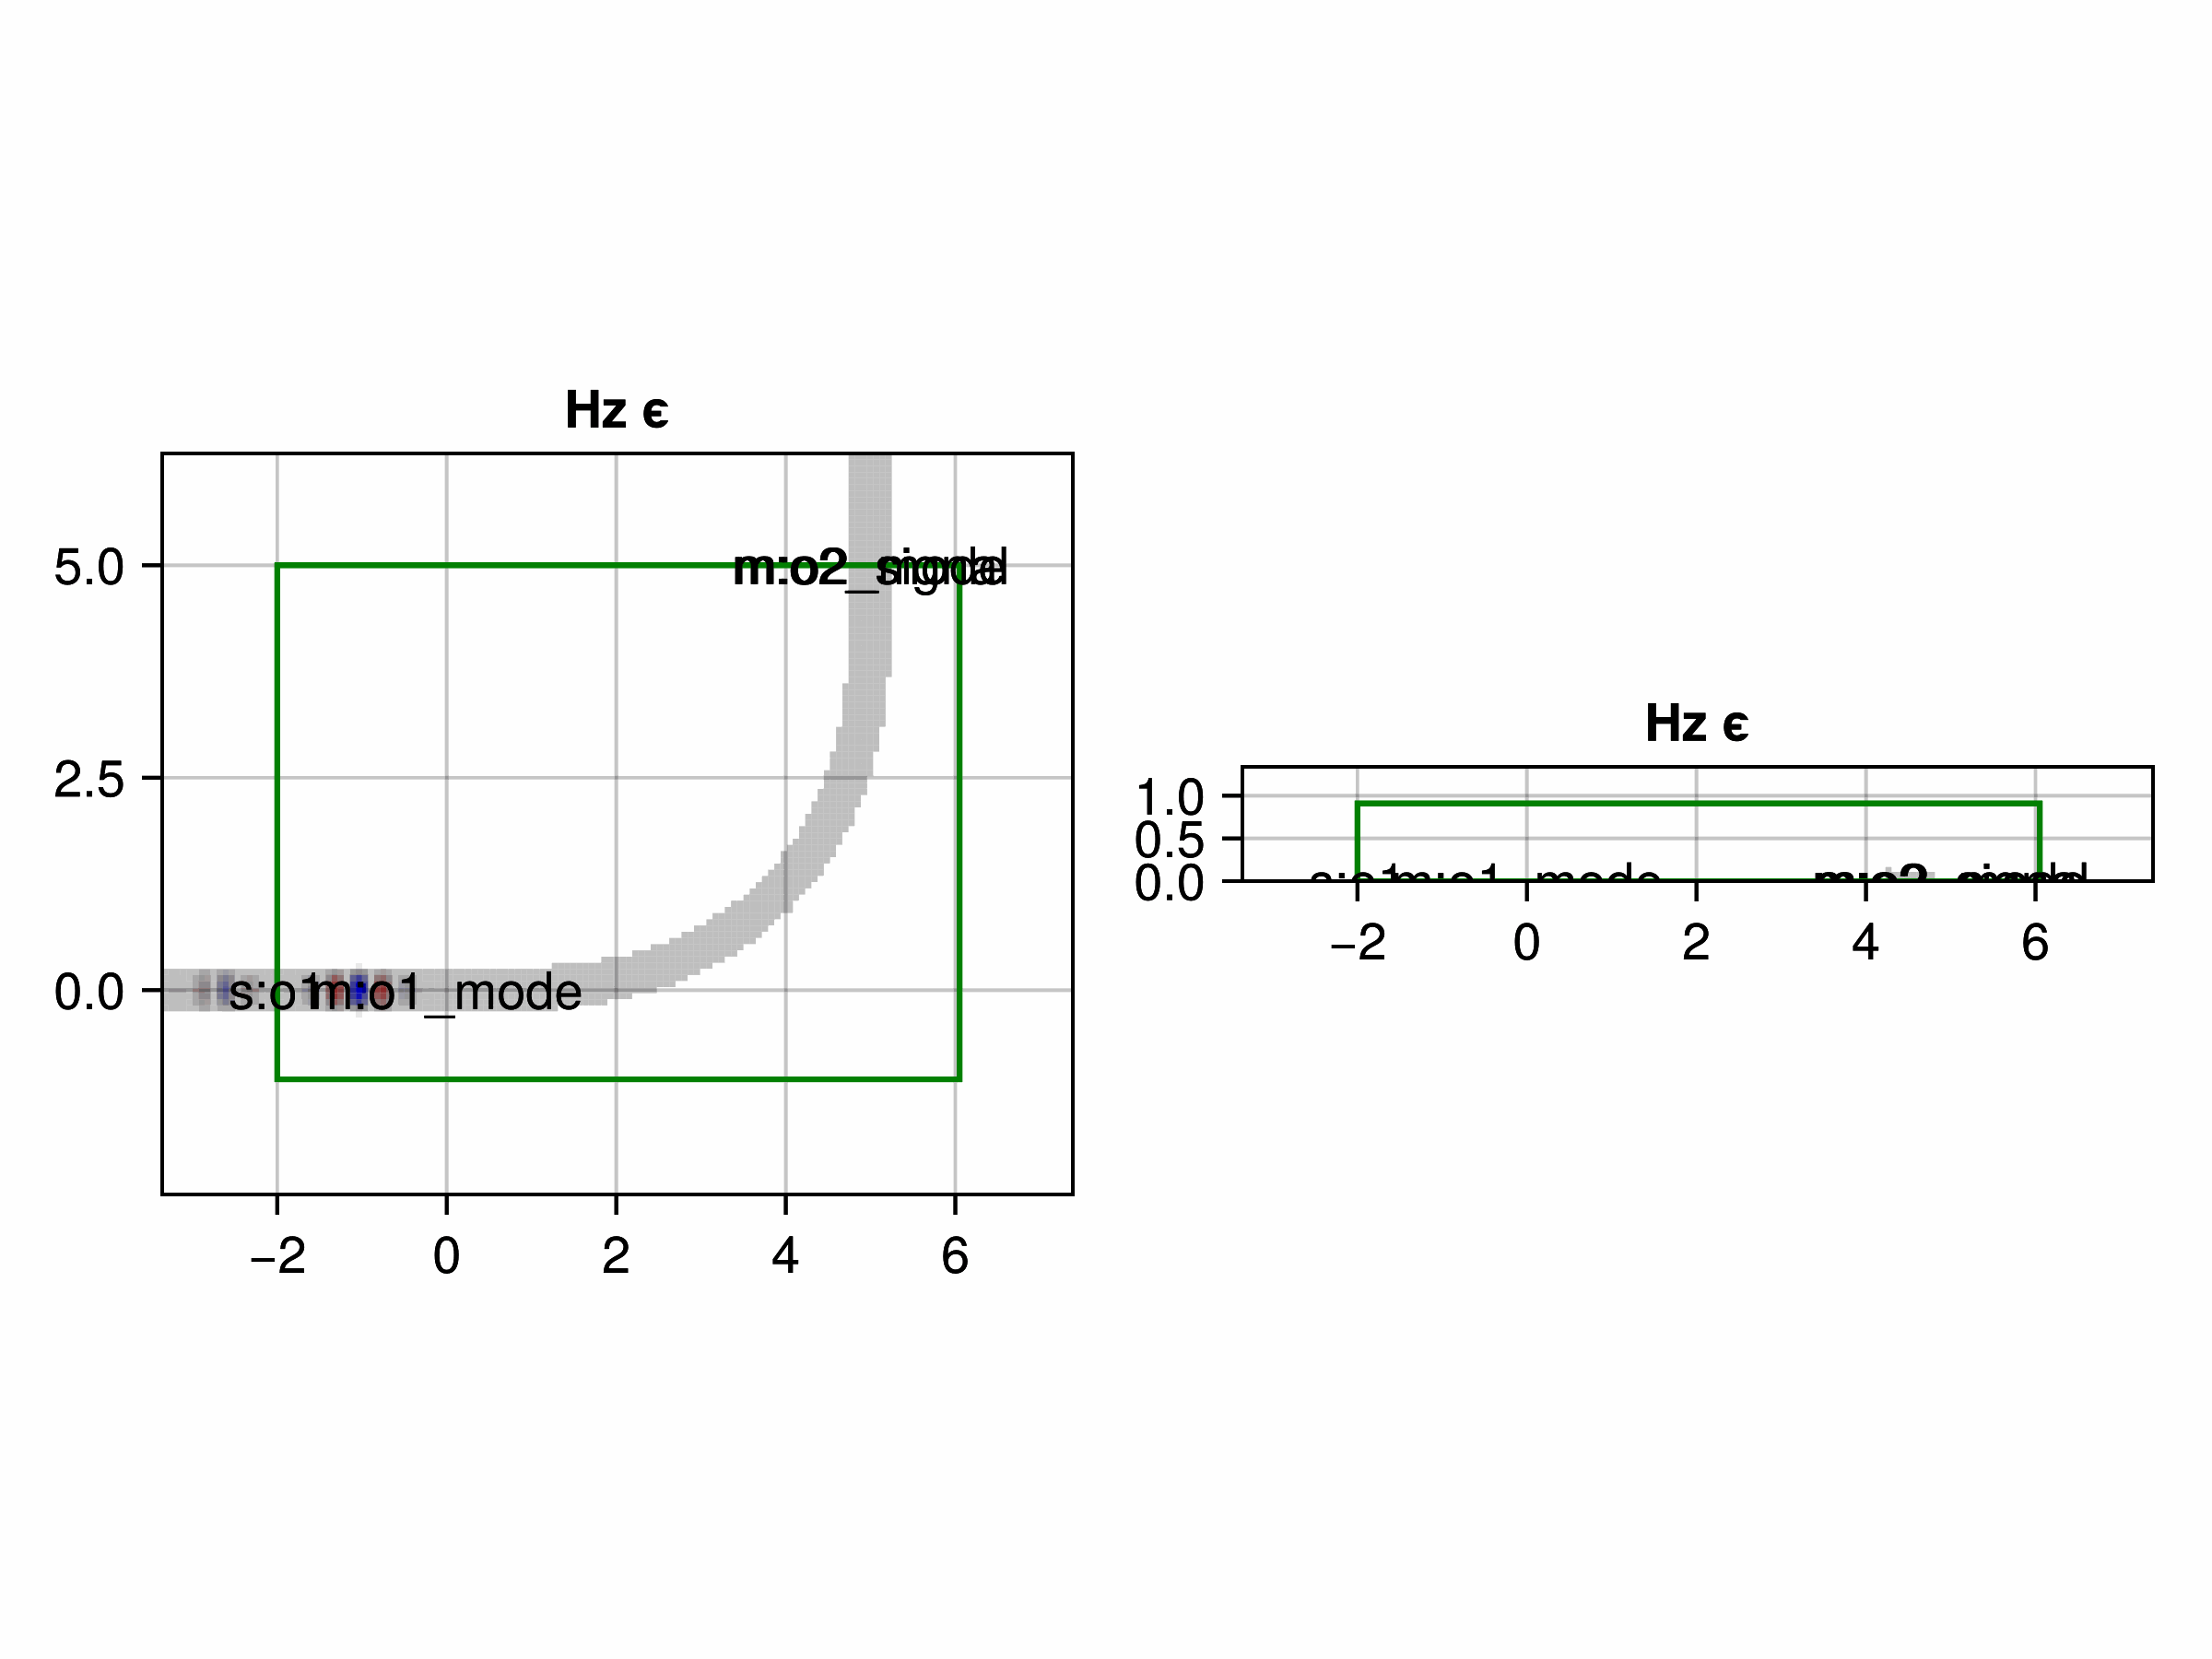

In [ ]:
lm.movie(path)

## Results

loading solution from c:\Users\weihu\OneDrive\Desktop\rock\moon\luminescent\runs\bend32
may take a minute if simulation folder is remotely mounted


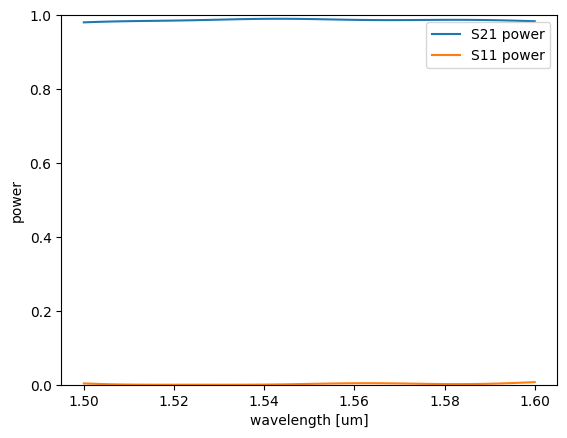

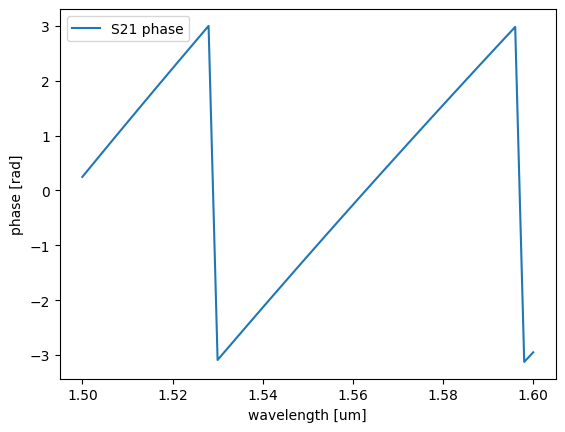

In [ ]:
sol = lm.load(path)
o2 = sol["monitors"]["o2_mode"]
o1 = sol["monitors"]["o1_mode"]

# + denotes forward propagating mode (wrt port monitor normal)
S21 = o2["modes"][0]["+"] / o1["modes"][0]["-"]
S11 = o1["modes"][0]["+"] / o1["modes"][0]["-"]

plt.figure()
plt.plot(wavelengths, np.abs(S21) ** 2, label="S21 power")
plt.plot(wavelengths, np.abs(S11) ** 2, label="S11 power")
plt.xlabel("wavelength [um]")
plt.ylabel("power")
plt.ylim(0, 1)
plt.legend()
plt.show()

plt.figure()
plt.plot(wavelengths, np.angle(S21), label="S21 phase")
plt.xlabel("wavelength [um]")
plt.ylabel("phase [rad]")
plt.legend()
plt.show()

C:\Users\weihu\AppData\Local\Temp\ipykernel_18236\1584231861.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


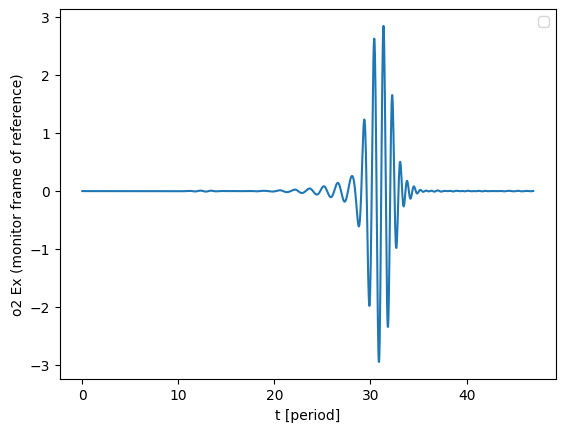

In [ ]:
t = sol["t"]
o2 = sol["monitors"]["o2_signal"]["signals"]["Ex"]

plt.figure()
plt.plot(t[: len(o2[0, :])], o2[0, :])
plt.xlabel("t [period]")
plt.ylabel("o2 Ex (monitor basis of reference)")
plt.legend()
plt.show()